# VQA Benchmark: 4 Model × RadImageNet-VQA (500 balanced samples)

Notebook này benchmark **4 cấu hình model** trên **500 mẫu cân bằng** từ `raidium/RadImageNet-VQA`:

| Tag | Loại | Base Model | Adapter |
|---|---|---|---|
| `base_2b` | Base, không fine-tune | `unsloth/gemma-4-E2B-it` | — |
| `ft_2b` | Fine-tuned LoRA | `unsloth/gemma-4-E2B-it` | `HoangVuSnape/gemma_2_lora_E2b @ checkpoint-400` |
| `base_4b` | Base, không fine-tune | `unsloth/gemma-4-E4B-it` | — |
| `ft_4b` | Fine-tuned LoRA | `unsloth/gemma-4-E4B-it` | `HoangVuSnape/gemma_4_lora_E4b @ checkpoint-400` |

**Dataset**: `raidium/RadImageNet-VQA` — config `benchmark`, split `test`  
**Test set**: 500 mẫu cân bằng 3 loại câu hỏi: `open` (~167) · `closed` (~167) · `multiple_choice` (~166)  
**Discord**: Thông báo kết quả sau mỗi model và sau khi hoàn thành toàn bộ benchmark.

## Block 0: Cài đặt thư viện

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
!pip install torchcodec
!pip install --no-deps --upgrade timm
!pip install pillow pandas tqdm requests

## Block 1: Config chung + Discord Webhook

In [2]:
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

from huggingface_hub import login

# ── HF Token + Discord Webhook ────────────────────────────────────────────────
# Lấy từ Kaggle Secrets (giống notebook training v3)
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["HF_TOKEN"]    = user_secrets.get_secret("HF_TOKEN")
    DISCORD_WEBHOOK_URL        = user_secrets.get_secret("DISCORD_WEBHOOK_URL")
    print("🔑 Đã nạp HF Token + Discord Webhook từ Kaggle Secrets!")
except Exception as e:
    try:
        from dotenv import load_dotenv
        load_dotenv()
        DISCORD_WEBHOOK_URL = os.environ.get("DISCORD_WEBHOOK_URL", "")
        print("🔑 Đã nạp từ file .env!")
    except Exception:
        os.environ["HF_TOKEN"] = "YOUR_HF_TOKEN"
        DISCORD_WEBHOOK_URL    = "YOUR_DISCORD_WEBHOOK_URL"
        print("⚠️ Điền HF_TOKEN và DISCORD_WEBHOOK_URL bằng tay.")

# ── Đăng nhập HF Hub ──────────────────────────────────────────────────────────
hf_token = os.environ.get("HF_TOKEN", "")
if hf_token and hf_token != "YOUR_HF_TOKEN":
    login(token=hf_token)
    print("🤗 Đăng nhập HF Hub thành công!")

# ── Model Specs ───────────────────────────────────────────────────────────────
MODEL_SPECS = {
    "base_2b": {
        "base_model_id": "unsloth/gemma-4-E2B-it",
        "adapter_id":    None,
        "checkpoint":    None,
    },
    "ft_2b": {
        "base_model_id": "unsloth/gemma-4-E2B-it",
        "adapter_id":    "HoangVuSnape/gemma_2_lora_E2b",
        "checkpoint":    "checkpoint-400",   # best val loss
    },
    "base_4b": {
        "base_model_id": "unsloth/gemma-4-E4B-it",
        "adapter_id":    None,
        "checkpoint":    None,
    },
    "ft_4b": {
        "base_model_id": "unsloth/gemma-4-E4B-it",
        "adapter_id":    "HoangVuSnape/gemma_4_lora_E4b",
        "checkpoint":    "checkpoint-400",   # best val loss
    },
}

# ── Dataset Config ────────────────────────────────────────────────────────────
DATASET_ID    = "raidium/RadImageNet-VQA"
DATASET_NAME  = "benchmark"
DATASET_SPLIT = "test"
SAMPLE_PER_TYPE = 167    # 167+167+166 = 500
TOTAL_SAMPLES   = 500
SEED = 42

# ── Generation Config ─────────────────────────────────────────────────────────
GEN_CONFIG = {
    "max_new_tokens": 64,
    "do_sample":      False,
}

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n📌 Device   : {DEVICE}")
print(f"📌 Dataset  : {DATASET_ID} / config={DATASET_NAME} / split={DATASET_SPLIT}")
print(f"📌 Samples  : {TOTAL_SAMPLES} (balanced ~{SAMPLE_PER_TYPE}/type)")
print(f"📌 Discord  : {'✅ configured' if DISCORD_WEBHOOK_URL and DISCORD_WEBHOOK_URL != 'YOUR_DISCORD_WEBHOOK_URL' else '⚠️ not configured'}")
print("\n📋 MODEL_SPECS:")
for tag, spec in MODEL_SPECS.items():
    ckpt = f" → {spec['checkpoint']}" if spec['checkpoint'] else ""
    print(f"  [{tag}] {spec['base_model_id']} | adapter: {spec['adapter_id']}{ckpt}")

🔑 Đã nạp HF Token + Discord Webhook từ Kaggle Secrets!


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


🤗 Đăng nhập HF Hub thành công!

📌 Device   : cuda
📌 Dataset  : raidium/RadImageNet-VQA / config=benchmark / split=test
📌 Samples  : 500 (balanced ~167/type)
📌 Discord  : ✅ configured

📋 MODEL_SPECS:
  [base_2b] unsloth/gemma-4-E2B-it | adapter: None
  [ft_2b] unsloth/gemma-4-E2B-it | adapter: HoangVuSnape/gemma_2_lora_E2b → checkpoint-400
  [base_4b] unsloth/gemma-4-E4B-it | adapter: None
  [ft_4b] unsloth/gemma-4-E4B-it | adapter: HoangVuSnape/gemma_4_lora_E4b → checkpoint-400


## Block 2: Discord Notification Function

Pattern lấy từ notebook training `v3-vqa-2b-it.ipynb` — gửi kết quả metrics lên Discord webhook.

In [3]:
import requests
import datetime

def send_discord_message(title: str, description: str, color: int = 0x5865F2, fields: list = None):
    """Gửi thông báo dạng embed chung lên Discord."""
    if not DISCORD_WEBHOOK_URL or DISCORD_WEBHOOK_URL == "YOUR_DISCORD_WEBHOOK_URL":
        print("⚠️ DISCORD_WEBHOOK_URL chưa được cấu hình — bỏ qua.")
        return

    timestamp = datetime.datetime.utcnow().isoformat() + "Z"
    embed = {
        "title":       title,
        "description": description,
        "color":       color,
        "fields":      fields or [],
        "footer":      {"text": f"VQA Benchmark | {timestamp[:19].replace('T', ' ')} UTC"},
    }
    payload = {
        "username": "🤖 VQA Benchmark Bot",
        "embeds":   [embed],
    }
    try:
        resp = requests.post(DISCORD_WEBHOOK_URL, json=payload, timeout=10)
        if resp.status_code in (200, 204):
            print(f"📨 Discord ✅ sent: {title}")
        else:
            print(f"⚠️ Discord send failed: HTTP {resp.status_code} — {resp.text[:200]}")
    except Exception as e:
        print(f"⚠️ Discord exception: {e}")

def send_discord_notification(title: str, metrics: dict, is_final: bool = False, extra_desc: str = ""):
    """Gửi thông báo kết quả benchmark lên Discord webhook."""
    if not DISCORD_WEBHOOK_URL or DISCORD_WEBHOOK_URL == "YOUR_DISCORD_WEBHOOK_URL":
        print("⚠️ DISCORD_WEBHOOK_URL chưa được cấu hình — bỏ qua.")
        return

    color     = 0x00FF7F if is_final else 0x5865F2   # xanh lá / indigo
    model_tag = metrics.get("model_tag", "N/A")

    # ── Build embed fields từ metrics ────────────────────────────────────────
    key_map = [
        ("n",                   "🔢 Samples"),
        ("exact_match",         "📊 Overall EM"),
        ("token_f1",            "📊 Overall F1"),
        ("em_open",             "🔓 EM Open"),
        ("f1_open",             "🔓 F1 Open"),
        ("em_closed",           "🔒 EM Closed"),
        ("f1_closed",           "🔒 F1 Closed"),
        ("em_multiple_choice",  "🔢 EM MultiChoice"),
        ("f1_multiple_choice",  "🔢 F1 MultiChoice"),
        ("avg_pred_len",        "📏 Avg Pred Len"),
    ]
    fields = []
    for key, label in key_map:
        if key in metrics and metrics[key] is not None:
            val  = metrics[key]
            unit = "" if key in {"n", "avg_pred_len"} else "%"
            fields.append({
                "name":   label,
                "value":  f"`{val:.2f}{unit}`" if isinstance(val, float) else f"`{val}`",
                "inline": True,
            })

    desc = (
        f"**Dataset**: `raidium/RadImageNet-VQA` — 500 mẫu balanced\n"
        f"**Model**: `{model_tag}`"
    )
    if extra_desc:
        desc += f"\n{extra_desc}"

    send_discord_message(title=title, description=desc, color=color, fields=fields)

print("✅ send_discord_notification() and send_discord_message() OK")
print("   Sẽ tự động gửi Discord sau mỗi model eval và sau khi benchmark hoàn thành.")

✅ send_discord_notification() and send_discord_message() OK
   Sẽ tự động gửi Discord sau mỗi model eval và sau khi benchmark hoàn thành.


## Block 3: Load & Chuẩn bị Test Data

Load `raidium/RadImageNet-VQA` — config `benchmark`, split `test`.  
Sample **500 mẫu cân bằng** theo 3 `question_type`: `open`, `closed`, `multiple_choice`.

In [4]:
from datasets import load_dataset
import random

# ── Load toàn bộ test split ────────────────────────────────────────────────
print(f"⏳ Loading {DATASET_ID} [{DATASET_NAME}] split={DATASET_SPLIT}...")
full_test = load_dataset(DATASET_ID, DATASET_NAME, split=DATASET_SPLIT)

print(f"\n📊 Full test split: {len(full_test)} mẫu")
print(f"📊 Columns: {full_test.column_names}")
print(f"📊 Features: {full_test.features}")

⏳ Loading raidium/RadImageNet-VQA [benchmark] split=test...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

benchmark/test-00000-of-00001.parquet:   0%|          | 0.00/361M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/9000 [00:00<?, ? examples/s]


📊 Full test split: 9000 mẫu
📊 Columns: ['image', 'question', 'choices', 'answer', 'question_type', 'metadata']
📊 Features: {'image': Image(mode=None, decode=True), 'question': Value('string'), 'choices': List(Value('string')), 'answer': Value('string'), 'question_type': Value('string'), 'metadata': {'content_type': Value('string'), 'correct_text': Value('string'), 'is_abnormal': Value('bool'), 'location': Value('string'), 'modality': Value('string'), 'pathology': Value('string'), 'question_id': Value('string')}}


In [5]:
# ── Khám phá phân phối question_type ──────────────────────────────────────
from collections import Counter

qtype_counts = Counter(full_test["question_type"])
print("📊 Phân phối question_type trong full test:")
for qtype, cnt in sorted(qtype_counts.items()):
    print(f"   {qtype:20s}: {cnt:6d} ({cnt/len(full_test)*100:.1f}%)")

# ── Xác nhận column answer ────────────────────────────────────────────────
print(f"\n📌 Các columns: {full_test.column_names}")
print("\n📌 Mẫu đầu tiên của từng question_type:")
for qtype in ["open", "closed", "multiple_choice"]:
    samples = [s for s in full_test if s["question_type"] == qtype]
    if samples:
        s = samples[0]
        print(f"\n  [{qtype}]")
        print(f"    question : {s['question']}")
        print(f"    choices  : {s.get('choices', None)}")
        ans_col = "answer" if "answer" in full_test.column_names else list(full_test.column_names)[3]
        print(f"    answer   : {s[ans_col]}")

📊 Phân phối question_type trong full test:
   closed              :   5000 (55.6%)
   multiple_choice     :   2000 (22.2%)
   open                :   2000 (22.2%)

📌 Các columns: ['image', 'question', 'choices', 'answer', 'question_type', 'metadata']

📌 Mẫu đầu tiên của từng question_type:

  [open]
    question : Name the organ featured in this image.
    choices  : None
    answer   : ankle foot

  [closed]
    question : Does the picture contain the ankle foot?
    choices  : None
    answer   : yes

  [multiple_choice]
    question : What is the correct anatomical region for this scan?
    choices  : ['hip', 'brain', 'spine', 'ankle foot']
    answer   : D


In [6]:
# ── Tạo 500 mẫu balanced ──────────────────────────────────────────────────
random.seed(SEED)

# Tự động detect tên column answer
ANSWER_COL = "answer" if "answer" in full_test.column_names else [
    c for c in full_test.column_names if c not in {"image", "question", "choices", "question_type", "metadata"}
][0]
print(f"✅ Answer column: '{ANSWER_COL}'")

QTYPES = ["open", "closed", "multiple_choice"]

# Tách theo type
idx_by_type = {}
for qtype in QTYPES:
    idx_by_type[qtype] = [i for i, s in enumerate(full_test) if s["question_type"] == qtype]
    print(f"   {qtype:20s}: {len(idx_by_type[qtype])} mẫu available")

# Sample cân bằng: 167 / 167 / 166 = 500
sampled_idx = []
for i, qtype in enumerate(QTYPES):
    n = SAMPLE_PER_TYPE if i < 2 else (TOTAL_SAMPLES - 2 * SAMPLE_PER_TYPE)
    pool = idx_by_type[qtype]
    chosen = random.sample(pool, min(n, len(pool)))
    sampled_idx.extend(chosen)
    print(f"   Sampled {qtype:20s}: {len(chosen)} mẫu")

# Sort để reproducible
sampled_idx = sorted(sampled_idx)
test_balanced = full_test.select(sampled_idx)

print(f"\n✅ test_balanced: {len(test_balanced)} mẫu (seed={SEED})")
print(f"   Phân phối: {Counter(test_balanced['question_type'])}")

✅ Answer column: 'answer'
   open                : 2000 mẫu available
   closed              : 5000 mẫu available
   multiple_choice     : 2000 mẫu available
   Sampled open                : 167 mẫu
   Sampled closed              : 167 mẫu
   Sampled multiple_choice     : 166 mẫu

✅ test_balanced: 500 mẫu (seed=42)
   Phân phối: Counter({'closed': 167, 'open': 167, 'multiple_choice': 166})


📋 MẪU DỮ LIỆU theo question_type:

[OPEN]
  Question: What abnormality is present in this scan?
  Answer  : meniscal abnormality


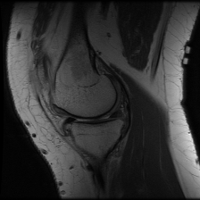


[CLOSED]
  Question: Is there evidence of soft tissue mass in this image?
  Answer  : no


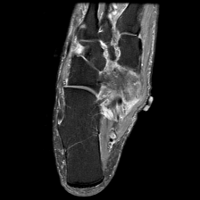


[MULTIPLE_CHOICE]
  Question: What is the most likely pathology in this image?
  Choices : ['airspace opacity', 'interstitial lung disease', 'no pathology seen', 'nodule']
  Answer  : A


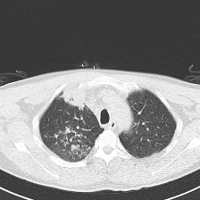

In [7]:
# ── Xem mẫu từ mỗi question_type ─────────────────────────────────────────
print("=" * 70)
print("📋 MẪU DỮ LIỆU theo question_type:")
print("=" * 70)

for qtype in QTYPES:
    sample = next(s for s in test_balanced if s["question_type"] == qtype)
    print(f"\n[{qtype.upper()}]")
    print(f"  Question: {sample['question']}")
    if sample.get("choices"):
        print(f"  Choices : {sample['choices']}")
    print(f"  Answer  : {sample[ANSWER_COL]}")
    display(sample["image"].resize((200, 200)))

## Block 4: Utility Functions

In [8]:
import re
from typing import List, Dict, Optional

# ── Answer normalization ──────────────────────────────────────────────────────
def normalize_answer(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_first_answer(text: str, max_words: int = 15) -> str:
    """Lấy câu trả lời ngắn từ output dài."""
    line = text.strip().split("\n")[0].strip()
    words = line.split()
    return " ".join(words[:max_words])

def get_gold_answer(sample: dict) -> str:
    """Lấy ground-truth answer theo question_type.
    - open/closed       : answer là text trực tiếp
    - multiple_choice   : answer là index → lấy choices[index]
    """
    qtype   = sample["question_type"]
    raw     = sample[ANSWER_COL]
    choices = sample.get("choices") or []

    if qtype == "multiple_choice" and choices:
        try:
            idx = int(raw)
            return str(choices[idx]) if 0 <= idx < len(choices) else str(raw)
        except (ValueError, TypeError):
            return str(raw)
    return str(raw)

# ── Metrics ──────────────────────────────────────────────────────────────────
def exact_match(pred: str, gold: str) -> int:
    return int(normalize_answer(pred) == normalize_answer(gold))

def token_f1(pred: str, gold: str) -> float:
    p_toks = normalize_answer(pred).split()
    g_toks = normalize_answer(gold).split()
    if not p_toks or not g_toks:
        return 0.0
    common = set(p_toks) & set(g_toks)
    if not common:
        return 0.0
    prec = sum(min(p_toks.count(t), g_toks.count(t)) for t in common) / len(p_toks)
    rec  = sum(min(p_toks.count(t), g_toks.count(t)) for t in common) / len(g_toks)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def compute_metrics(results: List[Dict]) -> Dict:
    """Aggregate metrics từ list {gold, pred, question_type}."""
    ems, f1s, pred_lens = [], [], []
    by_type = {qt: {"ems": [], "f1s": []} for qt in QTYPES}

    for r in results:
        em = exact_match(r["pred"], r["gold"])
        f1 = token_f1(r["pred"], r["gold"])
        ems.append(em)
        f1s.append(f1)
        pred_lens.append(len(r["pred"].split()))
        qt = r.get("question_type", "")
        if qt in by_type:
            by_type[qt]["ems"].append(em)
            by_type[qt]["f1s"].append(f1)

    metrics = {
        "n":            len(results),
        "exact_match":  round(sum(ems) / len(ems) * 100, 2),
        "token_f1":     round(sum(f1s) / len(f1s) * 100, 2),
        "avg_pred_len": round(sum(pred_lens) / len(pred_lens), 2),
    }
    for qt in QTYPES:
        data = by_type[qt]
        if data["ems"]:
            metrics[f"em_{qt}"] = round(sum(data["ems"]) / len(data["ems"]) * 100, 2)
            metrics[f"f1_{qt}"] = round(sum(data["f1s"]) / len(data["f1s"]) * 100, 2)
    return metrics

print("✅ Utility functions OK")
print("   normalize_answer | extract_first_answer | get_gold_answer")
print("   exact_match | token_f1 | compute_metrics")

✅ Utility functions OK
   normalize_answer | extract_first_answer | get_gold_answer
   exact_match | token_f1 | compute_metrics


## Block 5: Model Loader

In [9]:
import gc, torch
import os

def clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def load_base_model(base_model_id: str):
    from unsloth import FastModel
    print(f"\n🔄 Loading BASE: {base_model_id}")
    model, processor = FastModel.from_pretrained(
        model_name=base_model_id,
        max_seq_length=512,
        load_in_4bit=True,
        full_finetuning=False,
    )
    model = FastModel.for_inference(model)
    print(f"✅ Loaded: {base_model_id}")
    return model, processor

def load_finetune_model(base_model_id: str, adapter_id: str, checkpoint: Optional[str] = None):
    from unsloth import FastModel
    from peft import PeftModel

    print(f"\n🔄 Loading FINETUNE:")
    print(f"   Base    : {base_model_id}")
    print(f"   Adapter : {adapter_id}")
    if checkpoint:
        print(f"   Subfolder/Checkpoint: {checkpoint}")

    model, processor = FastModel.from_pretrained(
        model_name=base_model_id,
        max_seq_length=512,
        load_in_4bit=True,
        full_finetuning=False,
    )
    try:
        # Try local path if adapter_id/checkpoint exists locally
        local_path = os.path.join(adapter_id, checkpoint) if checkpoint else adapter_id
        if os.path.exists(local_path):
            print(f"   -> Found local adapter path: {local_path}")
            model = PeftModel.from_pretrained(model, local_path, is_trainable=False)
        else:
            # Try online Hugging Face Hub with subfolder parameter
            print(f"   -> Loading adapter from Hugging Face Hub...")
            if checkpoint:
                model = PeftModel.from_pretrained(
                    model, 
                    adapter_id, 
                    subfolder=checkpoint, 
                    is_trainable=False,
                    token=os.environ.get("HF_TOKEN") # <-- THÊM DÒNG NÀY
                )
            else:
                model = PeftModel.from_pretrained(
                    model, 
                    adapter_id, 
                    is_trainable=False,
                    token=os.environ.get("HF_TOKEN") # <-- VÀ THÊM CẢ VÀO ĐÂY NỮA
                )
        print(f"✅ Adapter loaded successfully!")
    except Exception as e:
        print(f"❌ Failed to load adapter: {e}")
        raise e

    model = FastModel.for_inference(model)
    return model, processor

def load_model_by_tag(tag: str):
    spec = MODEL_SPECS[tag]
    clear_vram()
    if spec["adapter_id"] is None:
        return load_base_model(spec["base_model_id"])
    return load_finetune_model(spec["base_model_id"], spec["adapter_id"], spec["checkpoint"])

print("✅ Model loader functions OK")

✅ Model loader functions OK


## Block 6: Inference Function

- **open / closed**: prompt thẳng câu hỏi, expect short answer.
- **multiple_choice**: thêm choices vào prompt, model chọn đáp án.

In [10]:
import torch
from PIL import Image

def build_question_text(sample: dict) -> str:
    """Tạo text câu hỏi, thêm choices nếu là multiple_choice."""
    q       = sample["question"]
    qtype   = sample["question_type"]
    choices = sample.get("choices") or []

    if qtype == "multiple_choice" and choices:
        opts = "\n".join([f"  {chr(65+i)}) {c}" for i, c in enumerate(choices)])
        return f"{q}\n\nOptions:\n{opts}\n\nAnswer with the correct option text only."
    return q

def run_inference(model, processor, sample: dict) -> str:
    """Inference 1 sample → predicted answer string."""
    image         = sample["image"].convert("RGB")
    question_text = build_question_text(sample)

    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question_text},
        ],
    }]

    text   = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=GEN_CONFIG["max_new_tokens"],
            do_sample=GEN_CONFIG["do_sample"],
        )

    input_len = inputs["input_ids"].shape[1]
    pred = processor.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    pred = extract_first_answer(pred)
    return pred

print("✅ Inference function OK")
print(f"   max_new_tokens={GEN_CONFIG['max_new_tokens']} | do_sample={GEN_CONFIG['do_sample']}")

✅ Inference function OK
   max_new_tokens=64 | do_sample=False


## Block 7: Quick Demo — 5 mẫu mỗi model

Test nhanh trước khi chạy full benchmark.

In [11]:
from tqdm.auto import tqdm
import pandas as pd
import traceback

def inference_demo(model_tag: str, n: int = 5):
    """Chạy n mẫu (ưu tiên 1 mẫu/type × 3 types)."""
    demo_samples = []
    for qt in QTYPES:
        candidates = [s for s in test_balanced if s["question_type"] == qt]
        if candidates:
            demo_samples.append(candidates[0])
    if len(demo_samples) < n:
        for s in test_balanced:
            if s not in demo_samples:
                demo_samples.append(s)
            if len(demo_samples) >= n:
                break
    demo_samples = demo_samples[:n]

    print(f"\n{'='*65}")
    print(f"🚀 Demo: [{model_tag}] — {n} mẫu")
    print(f"{'='*65}")

    send_discord_message(
        title=f"⏳ [Demo] Bắt đầu: {model_tag}",
        description=f"Bắt đầu load & chạy demo {n} mẫu cho model `{model_tag}`...",
        color=0xFEE75C
    )

    try:
        model, processor = load_model_by_tag(model_tag)
        rows = []
        for sample in tqdm(demo_samples, desc=f"[{model_tag}]"):
            gold = get_gold_answer(sample)
            pred = run_inference(model, processor, sample)
            rows.append({
                "type":     sample["question_type"],
                "question": sample["question"][:70],
                "gold":     gold,
                "pred":     pred,
                "em":       exact_match(pred, gold),
                "f1":       round(token_f1(pred, gold), 3),
            })

        df = pd.DataFrame(rows)
        pd.set_option("display.max_colwidth", 70)
        pd.set_option("display.width", 220)
        display(df)
        demo_em = df['em'].mean()*100
        demo_f1 = df['f1'].mean()*100
        print(f"\n📊 Demo EM={demo_em:.1f}% | F1={demo_f1:.1f}%")

        send_discord_message(
            title=f"✅ [Demo] Hoàn thành: {model_tag}",
            description=f"Hoàn thành demo {n} mẫu cho model `{model_tag}`.\n\n📊 **EM**: `{demo_em:.2f}%` · **F1**: `{demo_f1:.2f}%`",
            color=0x57F287
        )

        del model, processor
        clear_vram()
        return df

    except Exception as e:
        err_msg = f"Lỗi xảy ra khi demo model `{model_tag}`:\n```python\n{traceback.format_exc()[-1500:]}\n```"
        send_discord_message(
            title=f"❌ [Demo] LỖI: {model_tag}",
            description=err_msg,
            color=0xED4245
        )
        clear_vram()
        raise e

print("✅ inference_demo() OK")

✅ inference_demo() OK


In [12]:
df_demo_base2b = inference_demo("base_2b", n=5)


🚀 Demo: [base_2b] — 5 mẫu
📨 Discord ✅ sent: ⏳ [Demo] Bắt đầu: base_2b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!

🔄 Loading BASE: unsloth/gemma-4-E2B-it
==((====))==  Unsloth 2026.6.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

✅ Loaded: unsloth/gemma-4-E2B-it


[base_2b]:   0%|          | 0/5 [00:00<?, ?it/s]

,type,question,gold,pred,em,f1
0,open,What abnormality is present in this scan?,meniscal abnormality,"Based on the provided image, which appears to be a **Magnetic Reso...",0,0.0
1,closed,Is there evidence of soft tissue mass in this image?,no,"Based on the provided image, which appears to be a medical scan (l...",0,0.0
2,multiple_choice,What is the most likely pathology in this image?,A,B,0,0.0
3,closed,Does this scan reveal any abnormalities?,yes,"Based on the provided image, which appears to be an axial view fro...",0,0.0
4,closed,Is the ankle foot visible in the image?,no,"Based on the image provided, which is a **cross-sectional medical ...",0,0.0



📊 Demo EM=0.0% | F1=0.0%
📨 Discord ✅ sent: ✅ [Demo] Hoàn thành: base_2b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


In [14]:
df_demo_ft2b = inference_demo("ft_2b", n=5)


🚀 Demo: [ft_2b] — 5 mẫu
📨 Discord ✅ sent: ⏳ [Demo] Bắt đầu: ft_2b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"



🔄 Loading FINETUNE:
   Base    : unsloth/gemma-4-E2B-it
   Adapter : HoangVuSnape/gemma_2_lora_E2b
   Subfolder/Checkpoint: checkpoint-400
==((====))==  Unsloth 2026.6.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

   -> Loading adapter from Hugging Face Hub...


...

✅ Adapter loaded successfully!


[ft_2b]:   0%|          | 0/5 [00:00<?, ?it/s]

,type,question,gold,pred,em,f1
0,open,What abnormality is present in this scan?,meniscal abnormality,Osteoarthritis,0,0.000
1,closed,Is there evidence of soft tissue mass in this image?,no,no,1,1.000
2,multiple_choice,What is the most likely pathology in this image?,A,B) interstitial lung disease,0,0.000
3,closed,Does this scan reveal any abnormalities?,yes,"Yes, this scan reveals abnormalities in the lungs.",0,0.222
4,closed,Is the ankle foot visible in the image?,no,no,1,1.000



📊 Demo EM=40.0% | F1=44.4%
📨 Discord ✅ sent: ✅ [Demo] Hoàn thành: ft_2b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


In [15]:
df_demo_base4b = inference_demo("base_4b", n=5)


🚀 Demo: [base_4b] — 5 mẫu
📨 Discord ✅ sent: ⏳ [Demo] Bắt đầu: base_4b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"



🔄 Loading BASE: unsloth/gemma-4-E4B-it
==((====))==  Unsloth 2026.6.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

[base_4b]:   0%|          | 0/5 [00:00<?, ?it/s]

,type,question,gold,pred,em,f1
0,open,What abnormality is present in this scan?,meniscal abnormality,"I am sorry, but I cannot provide a medical diagnosis or interpret ...",0,0.0
1,closed,Is there evidence of soft tissue mass in this image?,no,"Based on the provided image, which appears to be a sagittal view o...",0,0.0
2,multiple_choice,What is the most likely pathology in this image?,A,B,0,0.0
3,closed,Does this scan reveal any abnormalities?,yes,"I am an AI, and **I am not a medical professional.** I cannot prov...",0,0.0
4,closed,Is the ankle foot visible in the image?,no,"Based on the image provided, which is a **cross-sectional CT scan ...",0,0.0



📊 Demo EM=0.0% | F1=0.0%


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


📨 Discord ✅ sent: ✅ [Demo] Hoàn thành: base_4b


In [16]:
df_demo_ft4b = inference_demo("ft_4b", n=5)


🚀 Demo: [ft_4b] — 5 mẫu
📨 Discord ✅ sent: ⏳ [Demo] Bắt đầu: ft_4b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"



🔄 Loading FINETUNE:
   Base    : unsloth/gemma-4-E4B-it
   Adapter : HoangVuSnape/gemma_4_lora_E4b
   Subfolder/Checkpoint: checkpoint-400
==((====))==  Unsloth 2026.6.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

   -> Loading adapter from Hugging Face Hub...


...

✅ Adapter loaded successfully!


[ft_4b]:   0%|          | 0/5 [00:00<?, ?it/s]

,type,question,gold,pred,em,f1
0,open,What abnormality is present in this scan?,meniscal abnormality,meniscal tear,0,0.5
1,closed,Is there evidence of soft tissue mass in this image?,no,no,1,1.0
2,multiple_choice,What is the most likely pathology in this image?,A,B) interstitial lung disease,0,0.0
3,closed,Does this scan reveal any abnormalities?,yes,yes,1,1.0
4,closed,Is the ankle foot visible in the image?,no,no,1,1.0



📊 Demo EM=60.0% | F1=70.0%
📨 Discord ✅ sent: ✅ [Demo] Hoàn thành: ft_4b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


## Block 8: Full Benchmark — 4 model × 500 mẫu

> ⚠️ **Ước tính**: mỗi model ~20-60 phút (T4/A100). Tổng ~2-4 giờ.  
> 📨 Discord sẽ tự động gửi thông báo sau mỗi model.

In [17]:
from tqdm.auto import tqdm
import pandas as pd
import traceback

def run_eval(model_tag: str) -> tuple:
    """Chạy eval trên toàn bộ test_balanced (500 mẫu)."""
    print(f"\n{'='*65}")
    print(f"🏃 Eval [{model_tag}] — {len(test_balanced)} mẫu")
    print(f"{'='*65}")

    send_discord_message(
        title=f"⏳ [Eval] Bắt đầu: {model_tag}",
        description=f"Bắt đầu load & chạy benchmark {len(test_balanced)} mẫu cho model `{model_tag}`...",
        color=0xFEE75C
    )

    try:
        model, processor = load_model_by_tag(model_tag)
        rows = []
        total = len(test_balanced)
        
        for i, sample in enumerate(tqdm(test_balanced, desc=model_tag)):
            gold = get_gold_answer(sample)
            pred = run_inference(model, processor, sample)
            rows.append({
                "model_tag":     model_tag,
                "idx":           i,
                "question_type": sample["question_type"],
                "question":      sample["question"],
                "gold":          gold,
                "pred":          pred,
                "em":            exact_match(pred, gold),
                "f1":            round(token_f1(pred, gold), 4),
            })
            
            # Gửi progress lên Discord mỗi 100 mẫu
            if (i + 1) % 100 == 0 or (i + 1) == total:
                temp_metrics = compute_metrics(rows)
                progress_desc = (
                    f"Đang benchmark model `{model_tag}`...\n"
                    f"Tiến trình: **{i + 1}/{total}** mẫu.\n\n"
                    f"📊 **EM tạm thời**: `{temp_metrics['exact_match']:.2f}%` · **F1 tạm thời**: `{temp_metrics['token_f1']:.2f}%`"
                )
                send_discord_message(
                    title=f"🔄 [Eval] {model_tag} progress",
                    description=progress_desc,
                    color=0x3498DB
                )

        metrics = compute_metrics(rows)
        metrics["model_tag"] = model_tag

        print(f"\n📊 [{model_tag}] Results:")
        print(f"   Overall  EM : {metrics['exact_match']:.2f}%")
        print(f"   Overall  F1 : {metrics['token_f1']:.2f}%")
        for qt in QTYPES:
            if f"em_{qt}" in metrics:
                print(f"   EM ({qt:15s}): {metrics[f'em_{qt}']:.2f}%  |  F1: {metrics[f'f1_{qt}']:.2f}%")

        del model, processor
        clear_vram()
        return rows, metrics

    except Exception as e:
        err_msg = f"Lỗi xảy ra khi benchmark model `{model_tag}` tại mẫu thứ `{len(rows)}`:\n```python\n{traceback.format_exc()[-1500:]}\n```"
        send_discord_message(
            title=f"❌ [Eval] LỖI: {model_tag}",
            description=err_msg,
            color=0xED4245
        )
        clear_vram()
        raise e

print("✅ run_eval() OK")

✅ run_eval() OK


In [18]:
# ── Chạy benchmark cho cả 4 model ────────────────────────────────────────────
MODEL_TAGS = ["base_2b", "ft_2b", "base_4b", "ft_4b"]

all_rows    = []
all_metrics = []

for model_tag in MODEL_TAGS:
    rows, metrics = run_eval(model_tag)
    all_rows.extend(rows)
    all_metrics.append(metrics)

    # Lưu partial sau mỗi model
    pd.DataFrame(all_rows).to_csv("benchmark_results_partial.csv", index=False)
    print(f"💾 Saved partial: {len(all_rows)} rows")

    # 📨 Gửi Discord thông báo kết quả sau mỗi model
    send_discord_notification(
        title=f"✅ [{model_tag}] eval hoàn thành!",
        metrics=metrics,
        is_final=False,
        extra_desc=f"Checkpoint: `{MODEL_SPECS[model_tag].get('checkpoint', 'N/A')}`",
    )

print("\n🎉 Full benchmark hoàn thành!")


🏃 Eval [base_2b] — 500 mẫu
📨 Discord ✅ sent: ⏳ [Eval] Bắt đầu: base_2b


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"



🔄 Loading BASE: unsloth/gemma-4-E2B-it
==((====))==  Unsloth 2026.6.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

✅ Loaded: unsloth/gemma-4-E2B-it


...

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

   -> Loading adapter from Hugging Face Hub...
✅ Adapter loaded successfully!


ft_4b:   0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


📨 Discord ✅ sent: 🔄 [Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [Eval] ft_4b progress

📊 [ft_4b] Results:
   Overall  EM : 31.60%
   Overall  F1 : 37.07%
   EM (open           ): 5.99%  |  F1: 10.18%
   EM (closed         ): 72.46%  |  F1: 72.46%
   EM (multiple_choice): 16.27%  |  F1: 28.51%
💾 Saved partial: 2000 rows
📨 Discord ✅ sent: ✅ [ft_4b] eval hoàn thành!

🎉 Full benchmark hoàn thành!


## Block 9: Kết Quả & So Sánh

In [19]:
import pandas as pd

# Load results
try:
    df_all = pd.DataFrame(all_rows)
except NameError:
    df_all = pd.read_csv("benchmark_results_partial.csv")
    print("📂 Loaded từ file")

try:
    df_metrics = pd.DataFrame(all_metrics)
except NameError:
    records = []
    for mt, grp in df_all.groupby("model_tag"):
        m = compute_metrics(grp.to_dict("records"))
        m["model_tag"] = mt
        records.append(m)
    df_metrics = pd.DataFrame(records)

print(f"Total rows: {len(df_all)}")
print(f"Models evaluated: {df_all['model_tag'].unique().tolist()}")

Total rows: 2000
Models evaluated: ['base_2b', 'ft_2b', 'base_4b', 'ft_4b']


In [20]:
# ── Bảng tổng hợp ─────────────────────────────────────────────────────────────
COLS = ["model_tag", "n", "exact_match", "token_f1",
        "em_open", "f1_open",
        "em_closed", "f1_closed",
        "em_multiple_choice", "f1_multiple_choice",
        "avg_pred_len"]

df_show = df_metrics[[c for c in COLS if c in df_metrics.columns]].copy()
df_show = df_show.set_index("model_tag")

order = [t for t in ["base_2b", "ft_2b", "base_4b", "ft_4b"] if t in df_show.index]
df_show = df_show.loc[order]

print("\n" + "=" * 80)
print("📋 BENCHMARK SUMMARY — raidium/RadImageNet-VQA (500 mẫu balanced)")
print("=" * 80)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
display(df_show)


📋 BENCHMARK SUMMARY — raidium/RadImageNet-VQA (500 mẫu balanced)


,n,exact_match,token_f1,em_open,f1_open,em_closed,f1_closed,em_multiple_choice,f1_multiple_choice,avg_pred_len
model_tag,,,,,,,,,,
base_2b,500,15.60,18.73,0.00,0.39,0.00,1.55,46.99,54.46,10.23
ft_2b,500,22.40,33.73,7.78,10.03,59.28,59.81,0.00,31.35,1.99
base_4b,500,16.60,19.30,0.00,1.90,0.00,3.90,50.00,52.29,9.78
ft_4b,500,31.60,37.07,5.99,10.18,72.46,72.46,16.27,28.51,1.69


In [21]:
# ── So sánh Base vs Finetune ──────────────────────────────────────────────────
print("\n📈 IMPROVEMENT: Finetune vs Base")
print("-" * 55)

for size in ["2b", "4b"]:
    base_tag = f"base_{size}"
    ft_tag   = f"ft_{size}"
    if base_tag in df_show.index and ft_tag in df_show.index:
        base_em = df_show.loc[base_tag, "exact_match"]
        ft_em   = df_show.loc[ft_tag, "exact_match"]
        base_f1 = df_show.loc[base_tag, "token_f1"]
        ft_f1   = df_show.loc[ft_tag, "token_f1"]
        print(f"\n  [{size.upper()} model]")
        print(f"    EM  : {base_em:.2f}% → {ft_em:.2f}%  (Δ = {ft_em - base_em:+.2f}%)")
        print(f"    F1  : {base_f1:.2f}% → {ft_f1:.2f}%  (Δ = {ft_f1 - base_f1:+.2f}%)")

# ── Per-type breakdown ────────────────────────────────────────────────────────
print("\n\n📊 PER-TYPE BREAKDOWN (Exact Match %):")
print("-" * 60)
header = f"{'Model':12s} | {'open':>8s} | {'closed':>8s} | {'mc':>8s} | {'overall':>8s}"
print(header)
print("-" * 60)
for tag in order:
    em_o  = df_show.loc[tag, "em_open"]            if "em_open" in df_show.columns else 0.0
    em_c  = df_show.loc[tag, "em_closed"]          if "em_closed" in df_show.columns else 0.0
    em_mc = df_show.loc[tag, "em_multiple_choice"] if "em_multiple_choice" in df_show.columns else 0.0
    em_all = df_show.loc[tag, "exact_match"]
    print(f"{tag:12s} | {em_o:>8.2f} | {em_c:>8.2f} | {em_mc:>8.2f} | {em_all:>8.2f}")


📈 IMPROVEMENT: Finetune vs Base
-------------------------------------------------------

  [2B model]
    EM  : 15.60% → 22.40%  (Δ = +6.80%)
    F1  : 18.73% → 33.73%  (Δ = +15.00%)

  [4B model]
    EM  : 16.60% → 31.60%  (Δ = +15.00%)
    F1  : 19.30% → 37.07%  (Δ = +17.77%)


📊 PER-TYPE BREAKDOWN (Exact Match %):
------------------------------------------------------------
Model        |     open |   closed |       mc |  overall
------------------------------------------------------------
base_2b      |     0.00 |     0.00 |    46.99 |    15.60
ft_2b        |     7.78 |    59.28 |     0.00 |    22.40
base_4b      |     0.00 |     0.00 |    50.00 |    16.60
ft_4b        |     5.99 |    72.46 |    16.27 |    31.60


In [22]:
# ── Lưu kết quả ───────────────────────────────────────────────────────────────
df_all.to_csv("benchmark_results_full.csv", index=False)
df_show.to_csv("benchmark_metrics_summary.csv")
print("💾 Đã lưu:")
print("   benchmark_results_full.csv     — chi tiết từng mẫu")
print("   benchmark_metrics_summary.csv  — tổng hợp metrics")

💾 Đã lưu:
   benchmark_results_full.csv     — chi tiết từng mẫu
   benchmark_metrics_summary.csv  — tổng hợp metrics


## Block 10: Error Analysis

In [23]:
def error_analysis(model_tag: str, question_type: str = None, n_show: int = 10):
    """Xem các mẫu predict sai."""
    df = df_all[df_all["model_tag"] == model_tag]
    if question_type:
        df = df[df["question_type"] == question_type]
    df_wrong = df[df["em"] == 0]

    label = f"[{model_tag}]" + (f" type={question_type}" if question_type else "")
    print(f"\n{'='*65}")
    print(f"🔍 Error Analysis: {label}")
    print(f"   Wrong: {len(df_wrong)}/{len(df)} ({len(df_wrong)/len(df)*100:.1f}%)")
    print(f"{'='*65}")

    cols = ["question_type", "question", "gold", "pred", "f1"]
    pd.set_option("display.max_colwidth", 70)
    display(df_wrong[[c for c in cols if c in df_wrong.columns]].head(n_show))

for tag in ["base_2b", "ft_2b", "base_4b", "ft_4b"]:
    try:
        error_analysis(tag, n_show=5)
    except Exception as e:
        print(f"⚠️ [{tag}] chưa có data: {e}")


🔍 Error Analysis: [base_2b]
   Wrong: 422/500 (84.4%)


,question_type,question,gold,pred,f1
0,closed,Is there evidence of soft tissue mass in this image?,no,"Based on the provided image, which appears to be a medical scan (l...",0.00
1,closed,Does this scan reveal any abnormalities?,yes,"Based on the provided image, which appears to be an axial view fro...",0.00
2,multiple_choice,What is the most likely pathology in this image?,A,B,0.00
3,closed,Is the ankle foot visible in the image?,no,"Based on the image provided, which is a **cross-sectional medical ...",0.00
4,open,What abnormality is present in this scan?,meniscal abnormality,"Based on the provided image, which appears to be a **Magnetic Reso...",0.00



🔍 Error Analysis: [ft_2b]
   Wrong: 388/500 (77.6%)


,question_type,question,gold,pred,f1
501,closed,Does this scan reveal any abnormalities?,yes,"Yes, this scan reveals abnormalities in the lungs.",0.22
502,multiple_choice,What is the most likely pathology in this image?,A,B) interstitial lung disease,0.00
504,open,What abnormality is present in this scan?,meniscal abnormality,Osteoarthritis,0.00
505,multiple_choice,What is the correct anatomical region for this scan?,D,D) abdomen,0.67
506,multiple_choice,Which of the following pathologies is present in this image?,C,B) no pathology seen,0.00



🔍 Error Analysis: [base_4b]
   Wrong: 417/500 (83.4%)


,question_type,question,gold,pred,f1
1000,closed,Is there evidence of soft tissue mass in this image?,no,"Based on the provided image, which appears to be a sagittal view o...",0.00
1001,closed,Does this scan reveal any abnormalities?,yes,"I am an AI, and **I am not a medical professional.** I cannot prov...",0.00
1002,multiple_choice,What is the most likely pathology in this image?,A,B,0.00
1003,closed,Is the ankle foot visible in the image?,no,"Based on the image provided, which is a **cross-sectional CT scan ...",0.00
1004,open,What abnormality is present in this scan?,meniscal abnormality,"I am sorry, but I cannot provide a medical diagnosis or interpret ...",0.00



🔍 Error Analysis: [ft_4b]
   Wrong: 342/500 (68.4%)


,question_type,question,gold,pred,f1
1502,multiple_choice,What is the most likely pathology in this image?,A,B) interstitial lung disease,0.00
1504,open,What abnormality is present in this scan?,meniscal abnormality,meniscal tear,0.50
1505,multiple_choice,What is the correct anatomical region for this scan?,D,abdomen,0.00
1506,multiple_choice,Which of the following pathologies is present in this image?,C,A) soft tissue fluid,0.00
1507,closed,Are there signs of labral pathology?,yes,no,0.00


## Block 11: Final Discord Summary

Gửi bảng tổng hợp kết quả toàn bộ 4 model lên Discord sau khi benchmark hoàn thành.

In [24]:
# ── Gửi Discord Summary tổng hợp cả 4 model ──────────────────────────────────
import datetime

if not DISCORD_WEBHOOK_URL or DISCORD_WEBHOOK_URL == "YOUR_DISCORD_WEBHOOK_URL":
    print("⚠️ DISCORD_WEBHOOK_URL chưa cấu hình.")
else:
    try:
        # Tạo bảng ASCII kết quả
        table_lines = [
            f"{'Model':12s} | {'EM%':>7s} | {'F1%':>7s} | {'EM_open':>7s} | {'EM_cls':>6s} | {'EM_mc':>6s}",
            "-" * 62,
        ]
        for m in all_metrics:
            tag = m.get("model_tag", "?")
            em  = m.get("exact_match", 0.0)
            f1  = m.get("token_f1", 0.0)
            eo  = m.get("em_open", 0.0)
            ec  = m.get("em_closed", 0.0)
            emc = m.get("em_multiple_choice", 0.0)
            table_lines.append(f"{tag:12s} | {em:>7.2f} | {f1:>7.2f} | {eo:>7.2f} | {ec:>6.2f} | {emc:>6.2f}")
        table_str = "\n".join(table_lines)

        # Tính improvement
        try:
            m_base2b = next(m for m in all_metrics if m["model_tag"] == "base_2b")
            m_ft2b   = next(m for m in all_metrics if m["model_tag"] == "ft_2b")
            m_base4b = next(m for m in all_metrics if m["model_tag"] == "base_4b")
            m_ft4b   = next(m for m in all_metrics if m["model_tag"] == "ft_4b")
            delta_2b = m_ft2b["exact_match"] - m_base2b["exact_match"]
            delta_4b = m_ft4b["exact_match"] - m_base4b["exact_match"]
            improvement = (
                f"📈 EM Improvement:\n"
                f"   2B: {m_base2b['exact_match']:.2f}% → {m_ft2b['exact_match']:.2f}%  (Δ = {delta_2b:+.2f}%)\n"
                f"   4B: {m_base4b['exact_match']:.2f}% → {m_ft4b['exact_match']:.2f}%  (Δ = {delta_4b:+.2f}%)"
            )
        except Exception:
            improvement = ""

        timestamp = datetime.datetime.utcnow().isoformat() + "Z"
        payload = {
            "username": "🤖 VQA Benchmark Bot",
            "embeds": [{
                "title":       "🎉 FULL BENCHMARK HOÀN THÀNH!",
                "description": (
                    f"**Dataset**: `raidium/RadImageNet-VQA` — 500 mẫu balanced\n"
                    f"**Checkpoint**: `checkpoint-400` (cả 2B & 4B)\n\n"
                    f"```\n{table_str}\n```\n\n"
                    f"{improvement}"
                ),
                "color":  0x00FF7F,
                "fields": [
                    {
                        "name":   "📁 Files saved",
                        "value":  "`benchmark_results_full.csv`\n`benchmark_metrics_summary.csv`",
                        "inline": False,
                    }
                ],
                "footer": {"text": f"Completed at {timestamp[:19].replace('T', ' ')} UTC"}
            }]
        }

        resp = requests.post(DISCORD_WEBHOOK_URL, json=payload, timeout=10)
        if resp.status_code in (200, 204):
            print("📨 Final summary sent to Discord! ✅")
        else:
            print(f"⚠️ Discord error: HTTP {resp.status_code}")
    except Exception as e:
        print(f"⚠️ Discord exception: {e}")

/tmp/ipykernel_58/3962760128.py:39: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


📨 Final summary sent to Discord! ✅


# Block 12

In [26]:
from datasets import load_dataset
import pandas as pd
from tqdm.auto import tqdm
import traceback

print("⏳ Loading flaviagiammarino/vqa-rad split=test...")
vqa_rad_test = load_dataset("flaviagiammarino/vqa-rad", split="test")
print(f"📊 VQA-RAD Test split: {len(vqa_rad_test)} mẫu")

# Phân loại câu hỏi VQA-RAD thành 'open' hoặc 'closed' dựa trên câu trả lời
vqa_rad_processed = []
for sample in vqa_rad_test:
    gold = str(sample["answer"]).strip()
    gold_lower = gold.lower()
    qtype = "closed" if gold_lower in ["yes", "no"] else "open"
    vqa_rad_processed.append({
        "image": sample["image"],
        "question": sample["question"],
        "question_type": qtype,
        "gold": gold,
    })

print(f"✅ Đã chuẩn bị xong {len(vqa_rad_processed)} mẫu VQA-RAD.")
qtypes_cnt = {"open": 0, "closed": 0}
for s in vqa_rad_processed:
    qtypes_cnt[s["question_type"]] += 1
print(f"   - Open-ended  : {qtypes_cnt['open']} mẫu")
print(f"   - Closed-ended: {qtypes_cnt['closed']} mẫu")

def run_eval_vqarad(model_tag: str) -> tuple:
    """Benchmark trên tập dữ liệu VQA-RAD (451 mẫu)."""
    print(f"\n{'='*65}")
    print(f"🏃 VQA-RAD Eval [{model_tag}] — {len(vqa_rad_processed)} mẫu")
    print(f"{'='*65}")

    send_discord_message(
        title=f"⏳ [VQA-RAD Eval] Bắt đầu: {model_tag}",
        description=f"Bắt đầu load & chạy benchmark {len(vqa_rad_processed)} mẫu VQA-RAD cho model `{model_tag}`...",
        color=0xFEE75C
    )

    try:
        model, processor = load_model_by_tag(model_tag)
        rows = []
        total = len(vqa_rad_processed)
        
        for i, sample in enumerate(tqdm(vqa_rad_processed, desc=f"VQA-RAD {model_tag}")):
            pred = run_inference(model, processor, sample)
            rows.append({
                "model_tag":     model_tag,
                "idx":           i,
                "question_type": sample["question_type"],
                "question":      sample["question"],
                "gold":          sample["gold"],
                "pred":          pred,
                "em":            exact_match(pred, sample["gold"]),
                "f1":            round(token_f1(pred, sample["gold"]), 4),
            })
            
            # Gửi tiến trình mỗi 100 mẫu
            if (i + 1) % 100 == 0 or (i + 1) == total:
                ems, f1s = [], []
                by_type = {"open": {"ems": [], "f1s": []}, "closed": {"ems": [], "f1s": []}}
                for r in rows:
                    em = r["em"]
                    f1 = r["f1"]
                    ems.append(em)
                    f1s.append(f1)
                    qt = r["question_type"]
                    if qt in by_type:
                        by_type[qt]["ems"].append(em)
                        by_type[qt]["f1s"].append(f1)
                
                temp_em = sum(ems) / len(ems) * 100
                temp_f1 = sum(f1s) / len(f1s) * 100
                
                progress_desc = (
                    f"Đang benchmark VQA-RAD `{model_tag}`...\n"
                    f"Tiến trình: **{i + 1}/{total}** mẫu.\n\n"
                    f"📊 **EM tạm thời**: `{temp_em:.2f}%` · **F1 tạm thời**: `{temp_f1:.2f}%`"
                )
                send_discord_message(
                    title=f"🔄 [VQA-RAD Eval] {model_tag} progress",
                    description=progress_desc,
                    color=0x3498DB
                )

        # Tính toán metrics cuối cùng
        ems, f1s = [], []
        by_type = {"open": {"ems": [], "f1s": []}, "closed": {"ems": [], "f1s": []}}
        for r in rows:
            em = r["em"]
            f1 = r["f1"]
            ems.append(em)
            f1s.append(f1)
            qt = r["question_type"]
            if qt in by_type:
                by_type[qt]["ems"].append(em)
                by_type[qt]["f1s"].append(f1)
                
        metrics = {
            "model_tag": model_tag,
            "n": len(rows),
            "exact_match": round(sum(ems) / len(ems) * 100, 2),
            "token_f1": round(sum(f1s) / len(f1s) * 100, 2),
            "em_open": round(sum(by_type["open"]["ems"]) / len(by_type["open"]["ems"]) * 100, 2) if by_type["open"]["ems"] else 0.0,
            "f1_open": round(sum(by_type["open"]["f1s"]) / len(by_type["open"]["f1s"]) * 100, 2) if by_type["open"]["f1s"] else 0.0,
            "em_closed": round(sum(by_type["closed"]["ems"]) / len(by_type["closed"]["ems"]) * 100, 2) if by_type["closed"]["ems"] else 0.0,
            "f1_closed": round(sum(by_type["closed"]["f1s"]) / len(by_type["closed"]["f1s"]) * 100, 2) if by_type["closed"]["f1s"] else 0.0,
        }

        print(f"\n📊 [{model_tag}] VQA-RAD Results:")
        print(f"   Overall  EM : {metrics['exact_match']:.2f}%")
        print(f"   Overall  F1 : {metrics['token_f1']:.2f}%")
        print(f"   EM (Open)   : {metrics['em_open']:.2f}% | F1: {metrics['f1_open']:.2f}%")
        print(f"   EM (Closed) : {metrics['em_closed']:.2f}% | F1: {metrics['f1_closed']:.2f}%")

        # Gửi kết quả cuối cùng của model này lên Discord
        send_discord_message(
            title=f"✅ [VQA-RAD Eval] Hoàn thành: {model_tag}",
            description=(
                f"**Dataset**: `flaviagiammarino/vqa-rad` (451 mẫu test)\n"
                f"**Model**: `{model_tag}`\n\n"
                f"📊 **Overall EM**: `{metrics['exact_match']:.2f}%` · **Overall F1**: `{metrics['token_f1']:.2f}%`\n"
                f"🔓 **EM (Open)**: `{metrics['em_open']:.2f}%` · **F1**: `{metrics['f1_open']:.2f}%`\n"
                f"🔒 **EM (Closed)**: `{metrics['em_closed']:.2f}%` · **F1**: `{metrics['f1_closed']:.2f}%`"
            ),
            color=0x00FF7F
        )

        del model, processor
        clear_vram()
        return rows, metrics

    except Exception as e:
        err_msg = f"Lỗi xảy ra khi benchmark VQA-RAD model `{model_tag}` tại mẫu thứ `{len(rows)}`:\n```python\n{traceback.format_exc()[-1500:]}\n```"
        send_discord_message(
            title=f"❌ [VQA-RAD Eval] LỖI: {model_tag}",
            description=err_msg,
            color=0xED4245
        )
        clear_vram()
        raise e

# Chạy benchmark VQA-RAD
vqa_rad_results = []
for tag in MODEL_TAGS:
    try:
        rows, m = run_eval_vqarad(tag)
        vqa_rad_results.append(m)
    except Exception:
        print(f"⚠️ Bỏ qua {tag} do lỗi.")
df_vqa_rad = pd.DataFrame(vqa_rad_results)
display(df_vqa_rad)
df_vqa_rad.to_csv("benchmark_vqa_rad_metrics_summary.csv", index=False)

⏳ Loading flaviagiammarino/vqa-rad split=test...
📊 VQA-RAD Test split: 451 mẫu
✅ Đã chuẩn bị xong 451 mẫu VQA-RAD.
   - Open-ended  : 200 mẫu
   - Closed-ended: 251 mẫu

🏃 VQA-RAD Eval [base_2b] — 451 mẫu


/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


📨 Discord ✅ sent: ⏳ [VQA-RAD Eval] Bắt đầu: base_2b

🔄 Loading BASE: unsloth/gemma-4-E2B-it
==((====))==  Unsloth 2026.6.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

✅ Loaded: unsloth/gemma-4-E2B-it


...

   -> Loading adapter from Hugging Face Hub...
✅ Adapter loaded successfully!


VQA-RAD ft_4b:   0%|          | 0/451 [00:00<?, ?it/s]

/tmp/ipykernel_58/118226932.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().isoformat() + "Z"


📨 Discord ✅ sent: 🔄 [VQA-RAD Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [VQA-RAD Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [VQA-RAD Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [VQA-RAD Eval] ft_4b progress
📨 Discord ✅ sent: 🔄 [VQA-RAD Eval] ft_4b progress

📊 [ft_4b] VQA-RAD Results:
   Overall  EM : 48.34%
   Overall  F1 : 53.58%
   EM (Open)   : 20.00% | F1: 31.82%
   EM (Closed) : 70.92% | F1: 70.92%
📨 Discord ✅ sent: ✅ [VQA-RAD Eval] Hoàn thành: ft_4b


,model_tag,n,exact_match,token_f1,em_open,f1_open,em_closed,f1_closed
0,base_2b,451,0.00,1.76,0.00,3.55,0.00,0.34
1,ft_2b,451,48.34,53.62,23.00,34.31,68.53,69.00
2,base_4b,451,0.00,3.56,0.00,5.12,0.00,2.32
3,ft_4b,451,48.34,53.58,20.00,31.82,70.92,70.92
